<a href="https://colab.research.google.com/github/jrebull/MIAAD_IngenieraDatos/blob/main/PySpark_MongoDB_SampleSupplies_Rebull.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PySpark con MongoDB Atlas — sample_supplies

---

**Programa:** Maestría en Inteligencia Artificial y Analítica de Datos (MIAAD)

**Materia:** Ingeniería de Datos Avanzada

**Profesor:** Dr. Vicente García Jiménez

**Alumno:** Javier Augusto Rebull Saucedo — Matrícula: 263483

**Fecha:** Abril 2026

---

**Objetivo de la Práctica:**
Conectar PySpark con MongoDB Atlas para leer la base de datos `sample_supplies`, explorar la colección `sales` como DataFrame, crear una vista temporal y ejecutar consultas con Spark SQL.

---

**Objetivos específicos**

- Configurar `SparkSession` en Colab con el MongoDB Spark Connector (V2, `_2.13`) usando `mongodb+srv`.
- Leer la colección `sales` como DataFrame e inspeccionar esquema, conteo y tipos.
- Crear la vista temporal `sales_view` y ejecutar las cinco consultas requeridas.
- Aplicar transformaciones y acciones sobre RDD.
- Visualizar los resultados con gráficas analíticas y un dashboard final.

In [1]:
#@title MIAAD · UACJ
from IPython.display import display, HTML

display(HTML("""
<table style="width:100%; border-collapse:collapse; background-color:#002B5C;
              border-radius:12px; overflow:hidden; font-family:Georgia,serif;">
  <tr>
    <td style="width:15%; padding:18px; text-align:center; vertical-align:middle;">
      <img src="https://www.uacj.mx/images/UACJ-LOGO.png"
           style="height:70px; filter:brightness(0) invert(1);" alt="UACJ"/>
    </td>
    <td style="padding:18px; text-align:center; vertical-align:middle;">
      <span style="color:#C8962E; font-size:22px; font-weight:bold; letter-spacing:2px;">
        MAESTRÍA EN INTELIGENCIA ARTIFICIAL Y ANALÍTICA DE DATOS
      </span><br/>
      <span style="color:#FFFFFF; font-size:16px;">
        Ingeniería de Datos Avanzada &nbsp;|&nbsp; Dr. Vicente García Jiménez
      </span><br/><br/>
      <span style="color:#C8962E; font-size:18px; font-weight:bold;">
        Práctica: PySpark + MongoDB Atlas — sample_supplies
      </span><br/>
      <span style="color:#AABBD6; font-size:13px;">
        Javier Augusto Rebull Saucedo &nbsp;|&nbsp; Matrícula: 263483 &nbsp;|&nbsp; Abril 2026
      </span>
    </td>
    <td style="width:13%; padding:18px; text-align:center; vertical-align:middle;">
      <img src="https://iili.io/qrfnJLv.jpg"
           style="height:70px; width:70px; border-radius:50%;
                  border:3px solid #C8962E; object-fit:cover;" alt="JARS"/>
    </td>
  </tr>
  <tr>
    <td colspan="3" style="background-color:#C8962E; padding:8px; text-align:center;">
      <span style="color:#002B5C; font-size:13px; font-weight:bold; letter-spacing:1px;">
        UNIVERSIDAD AUTÓNOMA DE CIUDAD JUÁREZ
      </span>
    </td>
  </tr>
</table>
"""))

## Marco Teórico

**Apache Spark** es un motor de procesamiento distribuido en memoria que permite ejecutar transformaciones y consultas SQL sobre grandes volúmenes de datos. A través del **MongoDB Spark Connector** (DataSource V2), es posible leer colecciones NoSQL directamente como `DataFrames`, aprovechando el optimizador Catalyst y el motor Tungsten de Spark [1][2].

La base de datos **`sample_supplies`** de MongoDB Atlas simula un sistema de ventas con documentos que incluyen campos anidados (`customer`, `items`) y arrays, lo que la convierte en un caso de uso ideal para explorar la lectura de documentos JSON complejos con PySpark [3][4].

| Componente | Descripción |
|---|---|
| `SparkSession` | Punto de entrada unificado a la API DataFrame/SQL de Spark |
| `MongoDB Spark Connector _2.13` | Conector oficial para Spark 4.x (compilado con Scala 2.13) |
| Cadena SRV | URI segura con TLS/SSL para autenticación en Atlas |
| `TempView + Spark SQL` | Vistas lógicas sobre DataFrames para consultas ANSI SQL |
| `RDD` | Resilient Distributed Dataset: capa de bajo nivel de Spark |

> **Nota de compatibilidad:** Spark 4.0 usa Scala 2.13, por lo que el conector debe ser `mongo-spark-connector_2.13`. Usar `_2.12` (para Spark 3.x) produce `NoSuchMethodError` en tiempo de ejecución [2].

In [2]:
# Verificar la versión e imprimir
print("Versión de PySpark:")
!pyspark --version

Versión de PySpark:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 4.0.2
      /_/
                        
Using Scala version 2.13.16, OpenJDK 64-Bit Server VM, 17.0.18
Branch HEAD
Compiled by user runner on 2026-02-02T08:08:13Z
Revision 7cc3b9bcdaab8c923f23cdbc9ce922530e1becf1
Url https://github.com/apache/spark
Type --help for more information.


## Configurar SparkSession con el MongoDB Spark Connector (DataSource V2)

Para conectar PySpark con MongoDB Atlas se requieren dos elementos:

1. **Cadena de conexión SRV**: obtenida en Atlas → Connect → Drivers. Tiene la forma `mongodb+srv://<usuario>:<password>@cluster0.xxxxx.mongodb.net/...`
2. **Conector Maven**: `org.mongodb.spark:mongo-spark-connector_2.13:10.5.0`, descargado automáticamente por Spark vía `spark.jars.packages`.

La URI se almacena en **Colab Secrets** (panel de llave 🔑) bajo el nombre `MONGODB_URI`. Si el Secret no está disponible, se usa `getpass` como fallback seguro.

In [3]:
#@title 🔗 Construir SparkSession con MongoDB Spark Connector (DataSource V2)
from pyspark.sql import SparkSession
from google.colab import userdata
import getpass

# ── Cargar URI desde Colab Secrets (o getpass como fallback) ──────────────────
try:
    MONGODB_URI = userdata.get('MONGODB_URI')
    print("✅ Cadena SRV cargada desde Colab Secrets")
except Exception:
    print("⚠️  Secret no encontrado. Ingresa tu password de Atlas:")
    password = getpass.getpass("Password de MongoDB Atlas (user_263483): ")
    MONGODB_URI = (
        f"mongodb+srv://user_263483:{password}"
        "@cluster0.1pg8t1c.mongodb.net/"
        "?retryWrites=true&w=majority&appName=Cluster0"
    )
    print("✅ URI construida con getpass")

# ── Conector compatible con Spark 4.x (Scala 2.13) ───────────────────────────
# IMPORTANTE: Spark 4.0 usa Scala 2.13. Usar _2.12 produce NoSuchMethodError.
MONGO_CONNECTOR = "org.mongodb.spark:mongo-spark-connector_2.13:10.5.0"

# ── Detener sesión previa si existe ──────────────────────────────────────────
try:
    spark.stop()
except Exception:
    pass

# ── Crear SparkSession ────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("MIAAD-263483-PySpark-MongoDB-SampleSupplies")
    .config("spark.mongodb.read.connection.uri",  MONGODB_URI)
    .config("spark.mongodb.write.connection.uri", MONGODB_URI)
    .config("spark.jars.packages", MONGO_CONNECTOR)
    .getOrCreate()
)

sc = spark.sparkContext

print(f"\n{'='*55}")
print(f"  Spark Version  : {spark.version}")
print(f"  App Name       : {spark.sparkContext.appName}")
print(f"  Master         : {spark.sparkContext.master}")
print(f"{'='*55}")
print("✅ SparkContext creado exitosamente")

✅ Cadena SRV cargada desde Colab Secrets

  Spark Version  : 4.0.2
  App Name       : MIAAD-263483-PySpark-MongoDB-SampleSupplies
  Master         : local[*]
✅ SparkContext creado exitosamente


## Lectura de la Colección `sales` desde MongoDB Atlas

`spark.read` con formato `"mongodb"` utiliza el conector V2 para leer la colección completa como un DataFrame distribuido. La inferencia de esquema (InferSchema) muestrea documentos de la colección para determinar los tipos de datos, incluyendo:

- Campos escalares: `storeLocation` (string), `couponUsed` (boolean), `purchaseMethod` (string)
- Campos anidados (STRUCT): `customer` con subcampos `age`, `gender`, `email`, `satisfaction`
- Campos de tipo array: `items` con objetos que contienen `name`, `price`, `quantity`, `tags`
- Timestamps: `saleDate`

In [4]:
#@title Leer colección sales como DataFrame

# Leer colección sample_supplies.sales como DataFrame
df_sales = (
    spark.read
    .format("mongodb")
    .option("database",   "sample_supplies")
    .option("collection", "sales")
    .load()
)

print("=" * 55)
print(f"  Total de registros (count): {df_sales.count():,}")
print("=" * 55)

print("\n── Schema de la colección sales ──────────────────────")
df_sales.printSchema()

print("\n── Tipos de datos (df.dtypes) ────────────────────────")
for col_name, col_type in df_sales.dtypes:
    print(f"  {col_name:<20} : {col_type}")

print("\n── Muestra de 3 documentos ───────────────────────────")
df_sales.show(3, truncate=60)

  Total de registros (count): 5,000

── Schema de la colección sales ──────────────────────
root
 |-- _id: string (nullable = true)
 |-- couponUsed: boolean (nullable = true)
 |-- customer: struct (nullable = true)
 |    |-- gender: string (nullable = true)
 |    |-- age: integer (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- satisfaction: integer (nullable = true)
 |-- items: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- name: string (nullable = true)
 |    |    |-- price: decimal(6,2) (nullable = true)
 |    |    |-- quantity: integer (nullable = true)
 |    |    |-- tags: array (nullable = true)
 |    |    |    |-- element: string (containsNull = true)
 |-- purchaseMethod: string (nullable = true)
 |-- saleDate: timestamp (nullable = true)
 |-- storeLocation: string (nullable = true)


── Tipos de datos (df.dtypes) ────────────────────────
  _id                  : string
  couponUsed           : boolean
  customer      

## Vistas Temporales y Spark SQL

**Spark SQL** es el módulo de Spark que permite trabajar con datos estructurados usando consultas SQL estándar (`SELECT`, `WHERE`, `GROUP BY`, `JOIN`, etc.) sobre DataFrames. Aprovecha el optimizador **Catalyst** y el motor **Tungsten** para ejecutar consultas de forma eficiente en clúster.

**¿Qué es una vista temporal?**

`createOrReplaceTempView("nombre")` registra el DataFrame como una tabla lógica en el catálogo de la sesión activa. Esta vista **no persiste** entre sesiones y **no crea datos físicos**; es un alias con esquema que Spark SQL puede consultar con sintaxis ANSI SQL [1][5].

In [5]:
# Crear vista temporal llamada sales_view
df_sales.createOrReplaceTempView("sales_view")
print("Vista temporal 'sales_view' creada exitosamente")

Vista temporal 'sales_view' creada exitosamente


In [6]:
#@title Consulta a) — COUNT total de documentos en sales_view
print("-" * 55)
print("  Consulta a) — Total de documentos en sales_view")
print("-" * 55)

query_a = spark.sql("""
    SELECT COUNT(*) AS total_documentos
    FROM   sales_view
""")
query_a.show()

-------------------------------------------------------
  Consulta a) — Total de documentos en sales_view
-------------------------------------------------------
+----------------+
|total_documentos|
+----------------+
|            5000|
+----------------+



In [7]:
#@title Consulta b) — Ventas por storeLocation (mayor a menor)
print("-" * 55)
print("  Consulta b) — GROUP BY storeLocation, ORDER DESC")
print("-" * 55)

query_b = spark.sql("""
    SELECT
        storeLocation                    AS sucursal,
        COUNT(*)                         AS total_ventas,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 2)   AS porcentaje_pct
    FROM   sales_view
    GROUP  BY storeLocation
    ORDER  BY total_ventas DESC
""")
query_b.show()

-------------------------------------------------------
  Consulta b) — GROUP BY storeLocation, ORDER DESC
-------------------------------------------------------
+---------+------------+--------------+
| sucursal|total_ventas|porcentaje_pct|
+---------+------------+--------------+
|   Denver|        1549|         30.98|
|  Seattle|        1134|         22.68|
|   London|         794|         15.88|
|   Austin|         676|         13.52|
| New York|         501|         10.02|
|San Diego|         346|          6.92|
+---------+------------+--------------+



In [8]:
#@title Consulta c) — Clientes con edad mayor a 42
print("-" * 55)
print("  Consulta c) — Clientes con customer.age > 42")
print("-" * 55)

# Los campos anidados (STRUCT) se acceden con notación de punto
query_c = spark.sql("""
    SELECT
        customer.gender       AS genero,
        customer.age          AS edad,
        customer.email        AS email,
        customer.satisfaction AS satisfaccion,
        storeLocation         AS sucursal,
        purchaseMethod        AS metodo_compra
    FROM   sales_view
    WHERE  customer.age > 42
    ORDER  BY customer.age DESC
    LIMIT  15
""")
query_c.show(truncate=40)

total_mayores = spark.sql(
    "SELECT COUNT(*) AS total FROM sales_view WHERE customer.age > 42"
).collect()[0][0]
print(f"Total de clientes con edad > 42: {total_mayores:,}")

-------------------------------------------------------
  Consulta c) — Clientes con customer.age > 42
-------------------------------------------------------
+------+----+-------------------+------------+---------+-------------+
|genero|edad|              email|satisfaccion| sucursal|metodo_compra|
+------+----+-------------------+------------+---------+-------------+
|     F|  75|          fok@ro.us|           5| New York|     In store|
|     M|  75|akeciban@koemoku.pe|           4|   London|       Online|
|     F|  75|     lef@mujluju.je|           5|   London|     In store|
|     F|  75|       kef@nubej.eh|           5|   Denver|       Online|
|     M|  75|         ah@fuuz.ke|           3|  Seattle|     In store|
|     M|  75|    wuzamfud@sur.mo|           3|   Denver|     In store|
|     F|  75|      edoos@tair.bi|           4|San Diego|     In store|
|     M|  75|        fa@gubif.gi|           5|   Denver|     In store|
|     M|  75|        kumog@se.cu|           4|San Diego|    

In [9]:
#@title  Consulta d) — Mínimo y máximo de customer.satisfaction
print("-" * 55)
print("  Consulta d) — MIN y MAX de customer.satisfaction")
print("-" * 55)

query_d = spark.sql("""
    SELECT
        MIN(customer.satisfaction)          AS satisfaccion_minima,
        MAX(customer.satisfaction)          AS satisfaccion_maxima,
        ROUND(AVG(customer.satisfaction), 3) AS satisfaccion_promedio,
        COUNT(*)                            AS documentos_con_satisfaction
    FROM   sales_view
    WHERE  customer.satisfaction IS NOT NULL
""")
query_d.show()

# Distribución detallada por nivel de satisfacción
print("  Distribución por nivel de satisfacción:")
spark.sql("""
    SELECT
        customer.satisfaction AS nivel,
        COUNT(*)              AS cantidad,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS porcentaje_pct
    FROM   sales_view
    WHERE  customer.satisfaction IS NOT NULL
    GROUP  BY customer.satisfaction
    ORDER  BY nivel
""").show()

-------------------------------------------------------
  Consulta d) — MIN y MAX de customer.satisfaction
-------------------------------------------------------
+-------------------+-------------------+---------------------+---------------------------+
|satisfaccion_minima|satisfaccion_maxima|satisfaccion_promedio|documentos_con_satisfaction|
+-------------------+-------------------+---------------------+---------------------------+
|                  1|                  5|                3.793|                       5000|
+-------------------+-------------------+---------------------+---------------------------+

  Distribución por nivel de satisfacción:
+-----+--------+--------------+
|nivel|cantidad|porcentaje_pct|
+-----+--------+--------------+
|    1|     388|          7.76|
|    2|     394|          7.88|
|    3|     818|         16.36|
|    4|    1664|         33.28|
|    5|    1736|         34.72|
+-----+--------+--------------+



In [10]:
#@title  Consulta e) — Ventas agrupadas por purchaseMethod
print("-" * 55)
print("  Consulta e) — GROUP BY purchaseMethod, ORDER")
print("-" * 55)

query_e = spark.sql("""
    SELECT
        purchaseMethod                       AS metodo_compra,
        COUNT(*)                             AS total_ventas,
        ROUND(AVG(customer.satisfaction), 3) AS satisfaccion_promedio,
        SUM(CASE WHEN couponUsed = true
                 THEN 1 ELSE 0 END)          AS cupones_usados,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER(), 2)       AS porcentaje_pct
    FROM   sales_view
    GROUP  BY purchaseMethod
    ORDER  BY total_ventas DESC
""")
query_e.show()

-------------------------------------------------------
  Consulta e) — GROUP BY purchaseMethod, ORDER
-------------------------------------------------------
+-------------+------------+---------------------+--------------+--------------+
|metodo_compra|total_ventas|satisfaccion_promedio|cupones_usados|porcentaje_pct|
+-------------+------------+---------------------+--------------+--------------+
|     In store|        2819|                3.796|           266|         56.38|
|       Online|        1585|                3.771|           148|         31.70|
|        Phone|         596|                3.837|            63|         11.92|
+-------------+------------+---------------------+--------------+--------------+



## Transformaciones y Acciones en RDD

El DataFrame de Spark tiene un RDD subyacente accesible vía `df.rdd`. Al convertirlo, cada fila se convierte en un objeto `Row` de PySpark, sobre el cual se pueden aplicar:

- **Transformaciones** (lazy): `map`, `filter`, `flatMap` — no se ejecutan hasta que se invoca una acción.
- **Acciones**: `count`, `first`, `take`, `collect`, `reduce` — desencadenan la ejecución del DAG.

> Una vez convertido a RDD no es posible ejecutar consultas Spark SQL directamente sobre él [1][5].

In [11]:
#@title  Transformaciones en RDD

# Convertir DataFrame a RDD
rdd_sales = df_sales.rdd
print(f"RDD creado con {rdd_sales.count():,} elementos\n")

print("=" * 55)
print("TRANSFORMACIONES RDD — sample_supplies.sales")
print("=" * 55)

# Transformación 1: MAP — extraer (storeLocation, purchaseMethod)
rdd_map = rdd_sales.map(lambda row: (row['storeLocation'], row['purchaseMethod']))
print("\n1. MAP — (storeLocation, purchaseMethod):")
for item in rdd_map.take(5):
    print(f"   {item}")

# Transformación 2: FILTER — ventas con cupón usado
rdd_cupon = rdd_sales.filter(lambda row: row['couponUsed'] is True)
print(f"\n2. FILTER — Ventas con cupón usado: {rdd_cupon.count():,}")

# Transformación 3: FILTER — clientes con edad > 42
def cliente_mayor_42(row):
    try:
        return int(row['customer']['age']) > 42
    except Exception:
        return False

rdd_mayores = rdd_sales.filter(cliente_mayor_42)
print(f"\n3. FILTER — Clientes con edad > 42: {rdd_mayores.count():,}")

# Transformación 4: FLATMAP — extraer nombres de todos los items vendidos
def extraer_items(row):
    try:
        items = row['items']
        return [item['name'] for item in items] if items else []
    except Exception:
        return []

rdd_items = rdd_sales.flatMap(extraer_items)
print(f"\n4. FLATMAP — Nombres de productos (primeros 8):")
print(f"   {rdd_items.take(8)}")

RDD creado con 5,000 elementos

TRANSFORMACIONES RDD — sample_supplies.sales

1. MAP — (storeLocation, purchaseMethod):
   ('Denver', 'Online')
   ('Seattle', 'Phone')
   ('Denver', 'In store')
   ('Seattle', 'In store')
   ('London', 'In store')

2. FILTER — Ventas con cupón usado: 477

3. FILTER — Clientes con edad > 42: 2,663

4. FLATMAP — Nombres de productos (primeros 8):
   ['printer paper', 'notepad', 'pens', 'backpack', 'notepad', 'envelopes', 'envelopes', 'binder']


In [12]:
#@title Acciones en RDD

print("=" * 55)
print("ACCIONES RDD — sample_supplies.sales")
print("=" * 55)

# Acción 1: COUNT
total = rdd_sales.count()
print(f"\n1. COUNT  — Total documentos : {total:,}")

# Acción 2: FIRST — primer documento
primer = rdd_sales.first()
print(f"\n2. FIRST  — Primera venta:")
print(f"   Sucursal        : {primer['storeLocation']}")
print(f"   Método          : {primer['purchaseMethod']}")
print(f"   Satisfacción    : {primer['customer']['satisfaction']}")
print(f"   Cupón usado     : {primer['couponUsed']}")

# Acción 3: TAKE
print(f"\n3. TAKE(5) — Primeras 5 ventas:")
for v in rdd_sales.take(5):
    print(f"   {v['storeLocation']:<12} | {v['purchaseMethod']:<10} | cupón={v['couponUsed']}")

# Acción 4: REDUCE — suma de satisfacción
suma_sat = (
    rdd_sales
    .map(lambda r: int(r['customer']['satisfaction'])
         if r['customer'] and r['customer']['satisfaction'] else 0)
    .reduce(lambda a, b: a + b)
)
print(f"\n4. REDUCE — Suma total de satisfaction : {suma_sat:,}")
print(f"            Promedio satisfaction      : {suma_sat/total:.3f}")

# Acción 5: COLLECT — solo si dataset pequeño
if total < 200:
    todos = rdd_sales.collect()
    print(f"\n5. COLLECT — {len(todos)} documentos recolectados")
else:
    print(f"\n5. COLLECT omitido — dataset con {total:,} registros (demasiado grande)")

ACCIONES RDD — sample_supplies.sales

1. COUNT  — Total documentos : 5,000

2. FIRST  — Primera venta:
   Sucursal        : Denver
   Método          : Online
   Satisfacción    : 4
   Cupón usado     : True

3. TAKE(5) — Primeras 5 ventas:
   Denver       | Online     | cupón=True
   Seattle      | Phone      | cupón=False
   Denver       | In store   | cupón=False
   Seattle      | In store   | cupón=False
   London       | In store   | cupón=False

4. REDUCE — Suma total de satisfaction : 18,966
            Promedio satisfaction      : 3.793

5. COLLECT omitido — dataset con 5,000 registros (demasiado grande)


## Análisis Visual

Los resultados de las consultas SQL se convierten a `pandas` DataFrames con `.toPandas()` para su visualización con `matplotlib`. A continuación se presentan cuatro gráficas exploratorias individuales seguidas del dashboard consolidado.

In [13]:
#@title Recolectar datos para visualización
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Paleta institucional UACJ
NAVY  = "#002B5C"
GOLD  = "#C8962E"
LIGHT = "#3A6BA8"
GRAY  = "#5C7A9E"
WHITE = "#FFFFFF"

pd_loc = spark.sql("""
    SELECT storeLocation AS sucursal, COUNT(*) AS ventas
    FROM   sales_view
    GROUP  BY storeLocation
    ORDER  BY ventas DESC
""").toPandas()

pd_meth = spark.sql("""
    SELECT purchaseMethod AS metodo, COUNT(*) AS total
    FROM   sales_view
    GROUP  BY purchaseMethod
    ORDER  BY total DESC
""").toPandas()

pd_sat = spark.sql("""
    SELECT customer.satisfaction AS nivel, COUNT(*) AS cantidad
    FROM   sales_view
    WHERE  customer.satisfaction IS NOT NULL
    GROUP  BY customer.satisfaction
    ORDER  BY nivel
""").toPandas()

pd_age = spark.sql("""
    SELECT storeLocation AS sucursal,
           ROUND(AVG(customer.age), 1) AS edad_promedio
    FROM   sales_view
    WHERE  customer.age IS NOT NULL
    GROUP  BY storeLocation
    ORDER  BY edad_promedio DESC
""").toPandas()

pd_monthly = spark.sql("""
    SELECT DATE_FORMAT(saleDate, 'yyyy-MM') AS mes, COUNT(*) AS ventas
    FROM   sales_view
    GROUP  BY DATE_FORMAT(saleDate, 'yyyy-MM')
    ORDER  BY mes
""").toPandas()

pd_sat_loc = spark.sql("""
    SELECT storeLocation AS sucursal,
           ROUND(AVG(customer.satisfaction), 2) AS sat_promedio
    FROM   sales_view
    WHERE  customer.satisfaction IS NOT NULL
    GROUP  BY storeLocation
    ORDER  BY sat_promedio DESC
""").toPandas()

pd_cupon_loc = spark.sql("""
    SELECT storeLocation AS sucursal,
           SUM(CASE WHEN couponUsed = true  THEN 1 ELSE 0 END) AS con_cupon,
           SUM(CASE WHEN couponUsed = false THEN 1 ELSE 0 END) AS sin_cupon
    FROM   sales_view
    GROUP  BY storeLocation
    ORDER  BY sucursal
""").toPandas()

# KPIs globales
total_ventas   = pd_loc['ventas'].sum()
sat_global     = spark.sql("SELECT ROUND(AVG(customer.satisfaction),3) AS s FROM sales_view").collect()[0][0]
pct_cupon      = spark.sql("SELECT ROUND(SUM(CASE WHEN couponUsed=true THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS p FROM sales_view").collect()[0][0]
total_ciudades = len(pd_loc)

print("Datos recolectados para visualización")
print(f"   Total ventas      : {total_ventas:,}")
print(f"   Satisfacción AVG  : {sat_global}")
print(f"   % Cupón usado     : {pct_cupon}%")
print(f"   Sucursales        : {total_ciudades}")

✅ Datos recolectados para visualización
   Total ventas      : 5,000
   Satisfacción AVG  : 3.793
   % Cupón usado     : 9.5%
   Sucursales        : 6


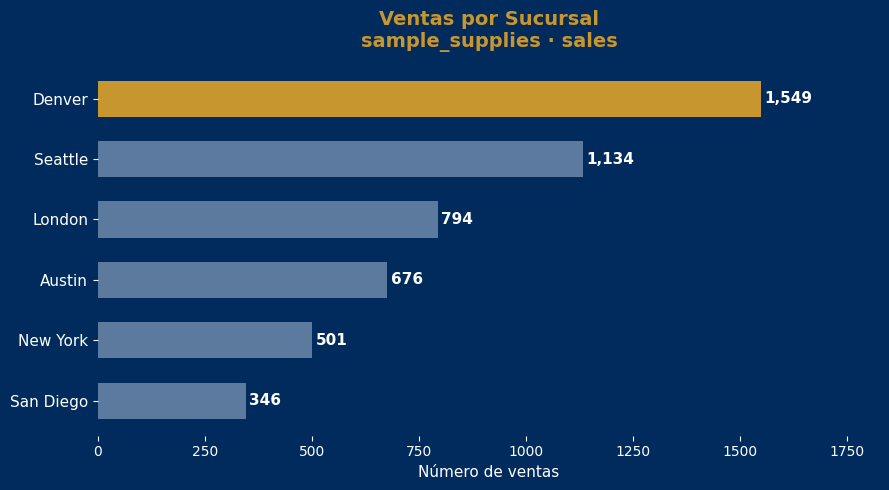

In [14]:
#@title Gráfica 1 — Ventas por sucursal

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

colores = [GOLD if i == 0 else GRAY for i in range(len(pd_loc))]
bars = ax.barh(pd_loc['sucursal'], pd_loc['ventas'],
               color=colores, edgecolor='none', height=0.6)

for bar, val in zip(bars, pd_loc['ventas']):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=WHITE, fontsize=11, fontweight='bold')

ax.set_xlabel('Número de ventas', color=WHITE, fontsize=11)
ax.set_title('Ventas por Sucursal\nsample_supplies · sales',
             color=GOLD, fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors=WHITE)
ax.spines[:].set_visible(False)
for label in ax.get_yticklabels():
    label.set_color(WHITE); label.set_fontsize(11)
ax.set_xlim(0, pd_loc['ventas'].max() * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

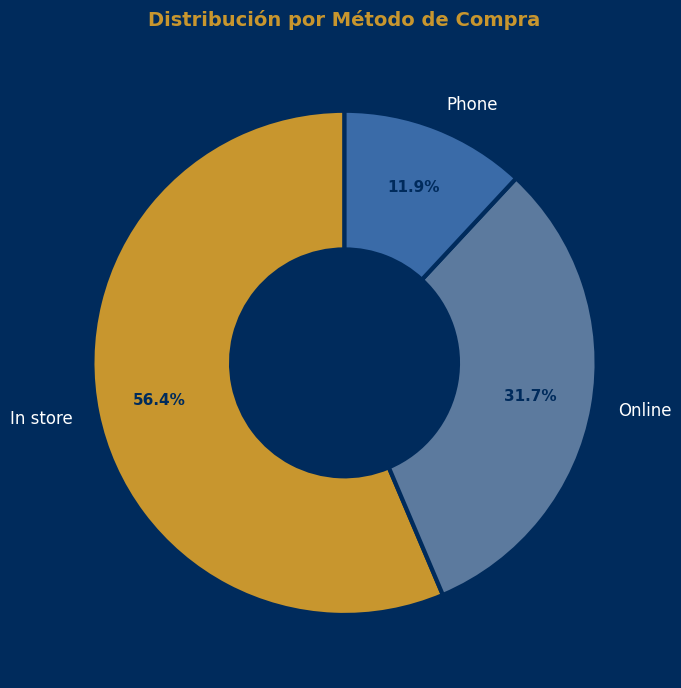

In [15]:
#@title Gráfica 2 — Distribución por método de compra

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

colores_pie = [GOLD, GRAY, LIGHT]
wedge_props = dict(width=0.55, edgecolor=NAVY, linewidth=3)
wedges, texts, autotexts = ax.pie(
    pd_meth['total'], labels=pd_meth['metodo'],
    autopct='%1.1f%%', colors=colores_pie,
    wedgeprops=wedge_props, startangle=90, pctdistance=0.75)

for t in texts:    t.set_color(WHITE); t.set_fontsize(12)
for at in autotexts: at.set_color(NAVY); at.set_fontsize(11); at.set_fontweight('bold')

ax.set_title('Distribución por Método de Compra',
             color=GOLD, fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

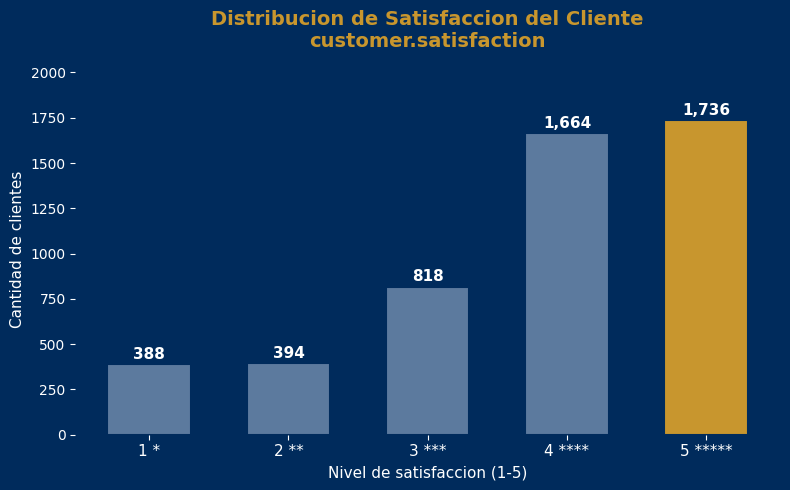

In [21]:
#@title Gráfica 3 — Distribución de satisfacción del cliente

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

palette = [GRAY, GRAY, GRAY, GRAY, GOLD]
niveles = pd_sat['nivel'].tolist()

bars = ax.bar(niveles, pd_sat['cantidad'],
              color=palette, edgecolor=NAVY, linewidth=1.5, width=0.6)

for bar, val in zip(bars, pd_sat['cantidad']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}', ha='center', va='bottom',
            color=WHITE, fontsize=11, fontweight='bold')

ax.set_xlabel('Nivel de satisfaccion (1-5)', color=WHITE, fontsize=11)
ax.set_ylabel('Cantidad de clientes', color=WHITE, fontsize=11)
ax.set_title('Distribucion de Satisfaccion del Cliente\ncustomer.satisfaction',
             color=GOLD, fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors=WHITE)
ax.spines[:].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color(WHITE)

# Fix: FixedLocator primero, luego labels
ax.set_xticks(niveles)
ax.set_xticklabels(['1 *', '2 **', '3 ***', '4 ****', '5 *****'], fontsize=11)

ax.set_ylim(0, pd_sat['cantidad'].max() * 1.18)
plt.tight_layout()
plt.show()

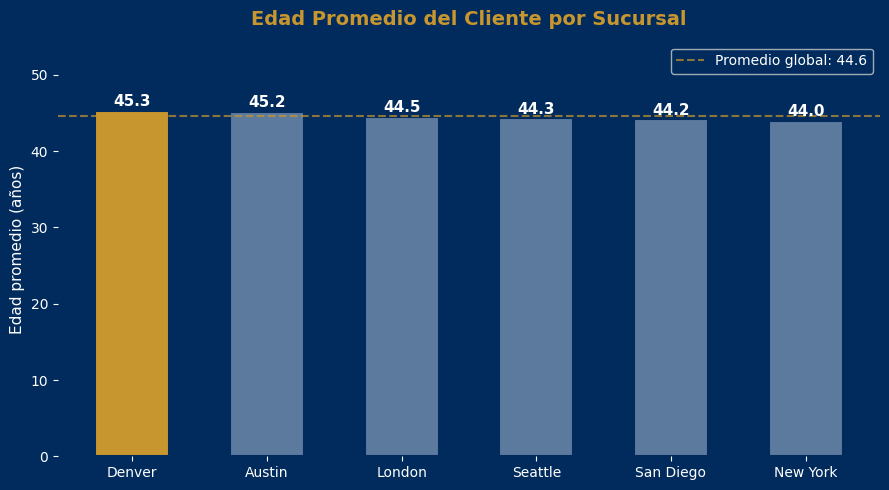

In [17]:
#@title Gráfica 4 — Edad promedio del cliente por sucursal

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

colores_edad = [GOLD if v == pd_age['edad_promedio'].max() else GRAY
                for v in pd_age['edad_promedio']]
bars = ax.bar(pd_age['sucursal'], pd_age['edad_promedio'],
              color=colores_edad, edgecolor=NAVY, linewidth=1.5, width=0.55)

for bar, val in zip(bars, pd_age['edad_promedio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}', ha='center', va='bottom',
            color=WHITE, fontsize=11, fontweight='bold')

ax.axhline(y=float(pd_age['edad_promedio'].mean()), color=GOLD,
           linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Promedio global: {pd_age["edad_promedio"].mean():.1f}')

ax.set_ylabel('Edad promedio (años)', color=WHITE, fontsize=11)
ax.set_title('Edad Promedio del Cliente por Sucursal',
             color=GOLD, fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors=WHITE)
ax.spines[:].set_visible(False)
ax.set_ylim(0, pd_age['edad_promedio'].max() * 1.2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color(WHITE)
ax.legend(facecolor=NAVY, labelcolor=WHITE, fontsize=10)
plt.tight_layout()
plt.show()

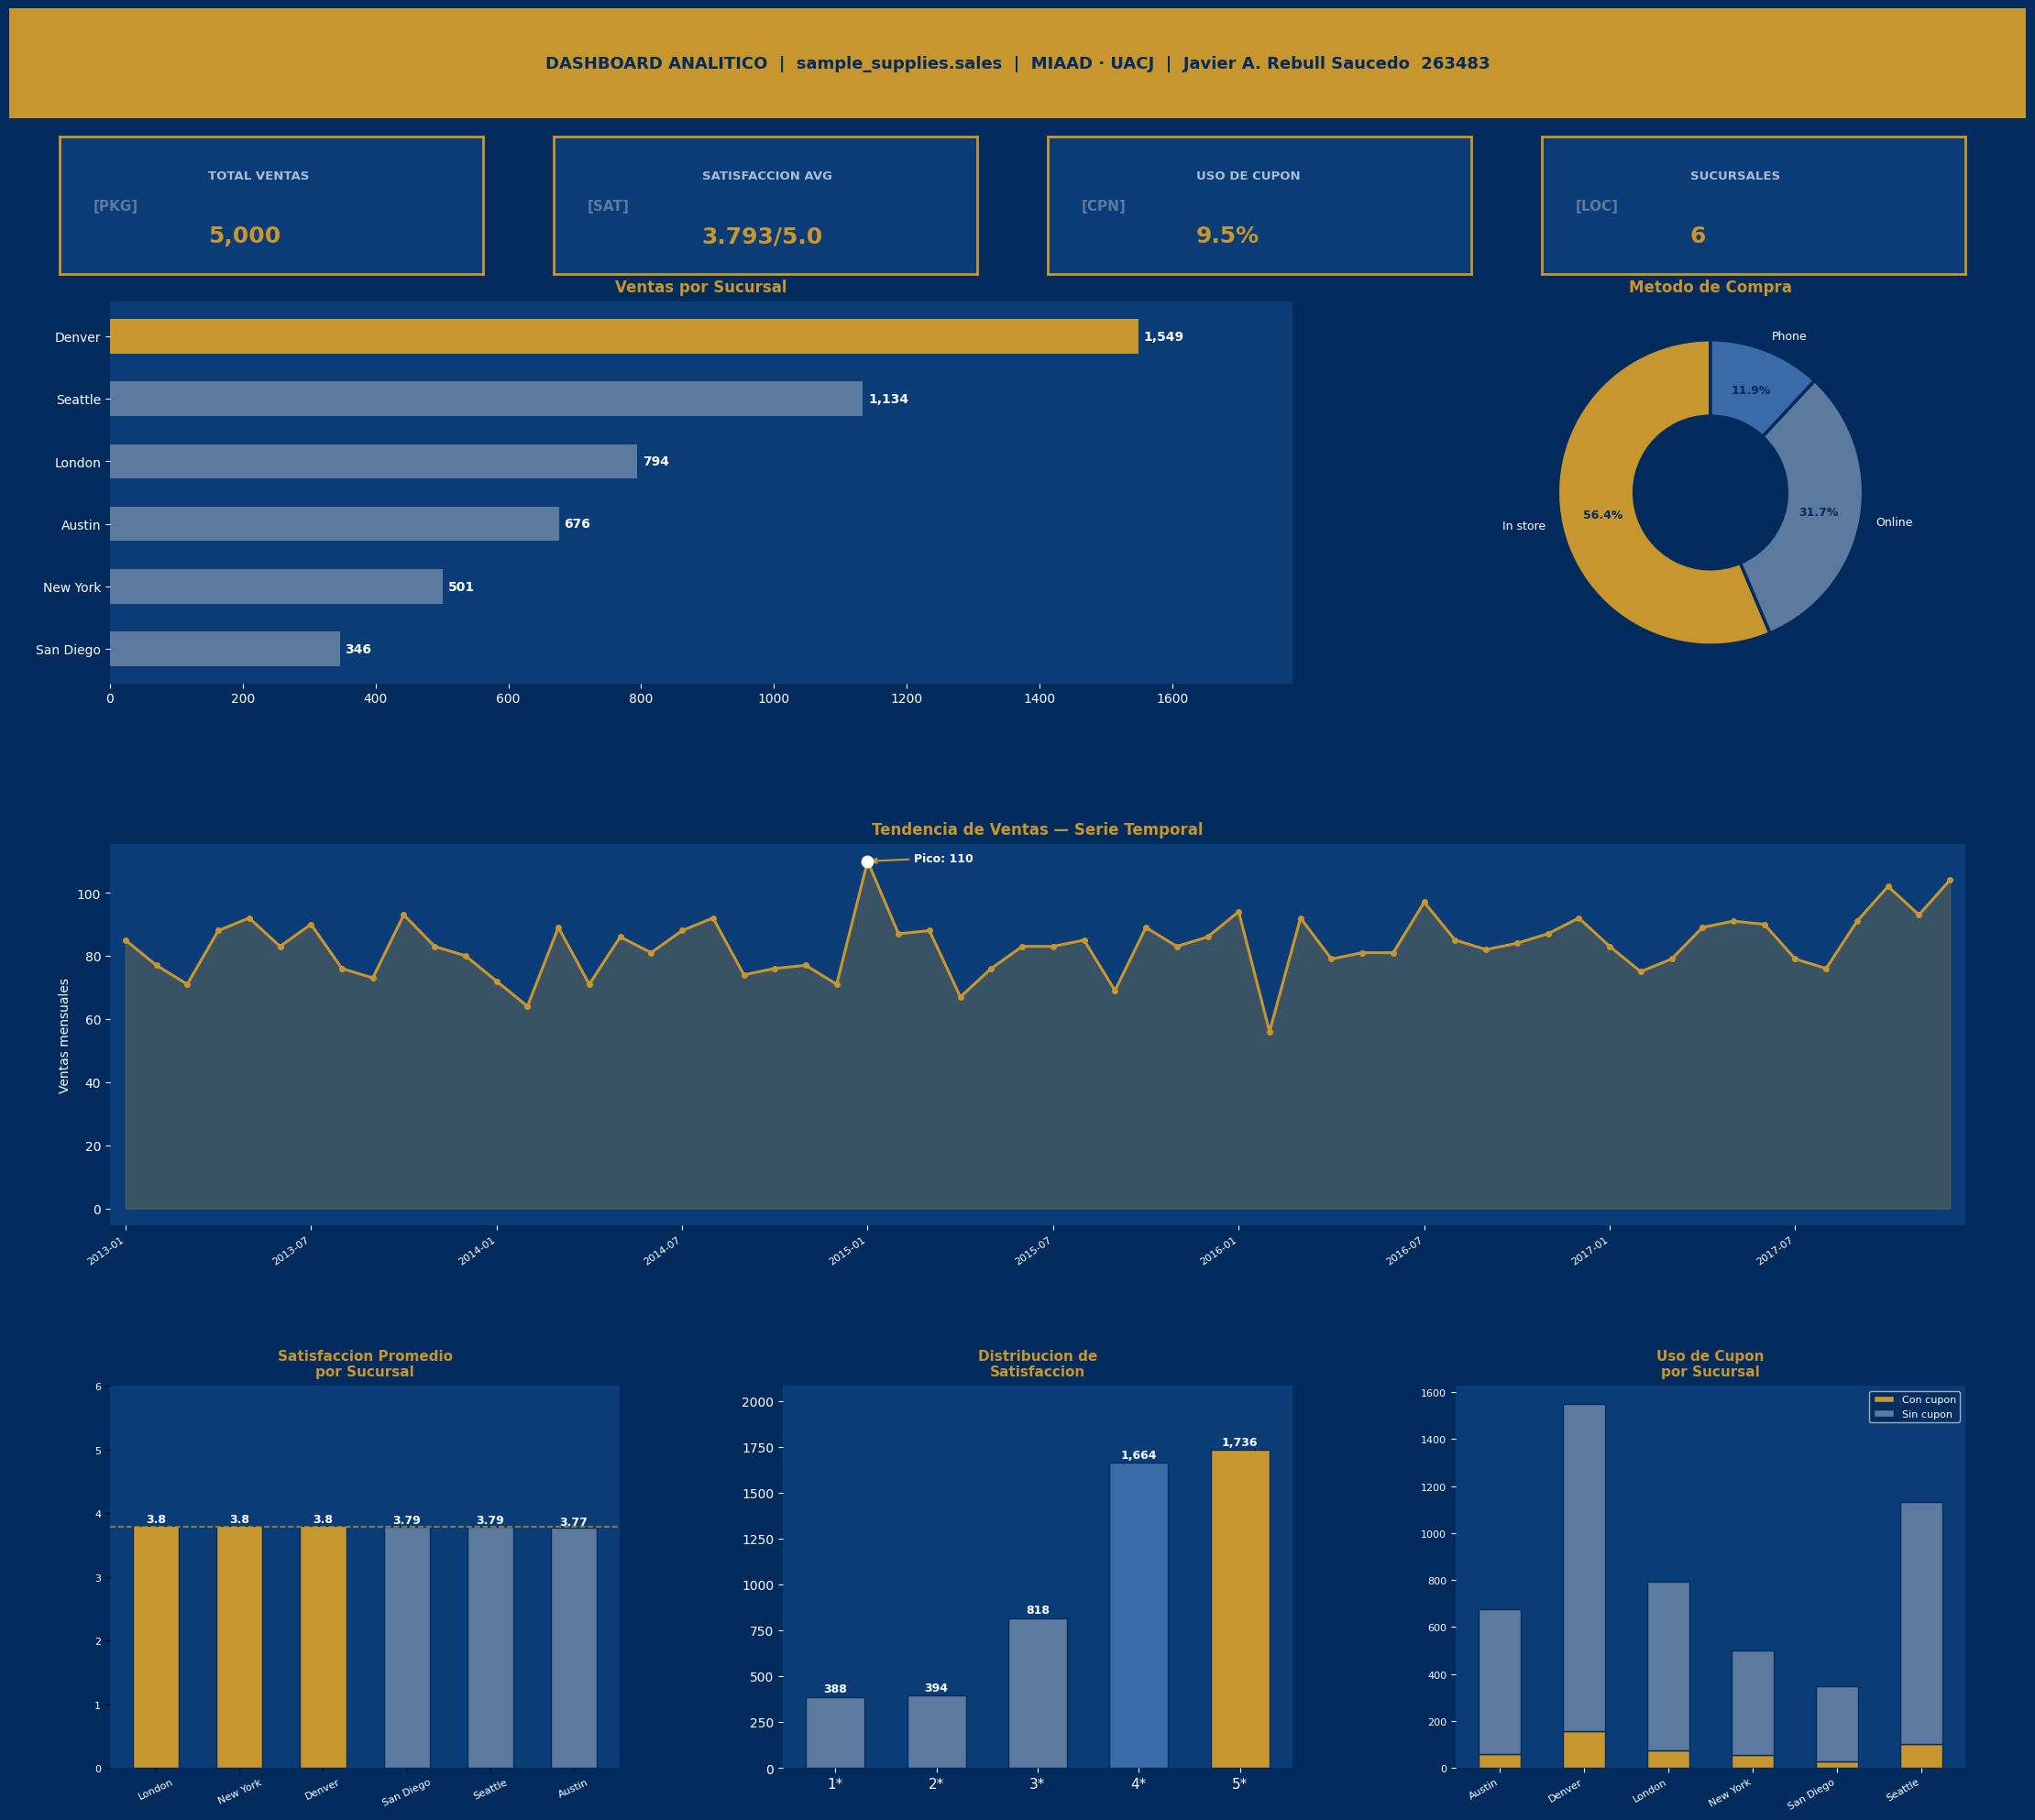

Dashboard guardado como dashboard_final_263483.png


In [20]:
#@title  DASHBOARD ANALÍTICO FINAL — sample_supplies

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(NAVY)

# ── Banner superior ───────────────────────────────────────────────────────────
ax_banner = fig.add_axes([0, 0.94, 1, 0.06])
ax_banner.set_facecolor(GOLD)
ax_banner.text(0.5, 0.5,
    "DASHBOARD ANALITICO  |  sample_supplies.sales  |  MIAAD · UACJ  |  Javier A. Rebull Saucedo  263483",
    ha='center', va='center', fontsize=13, fontweight='bold',
    color=NAVY, transform=ax_banner.transAxes)
ax_banner.set_xticks([]); ax_banner.set_yticks([])
for spine in ax_banner.spines.values(): spine.set_visible(False)

# ── KPI Cards (sin emojis — texto plano para DejaVu Sans) ────────────────────
kpi_data = [
    ("TOTAL VENTAS",     f"{total_ventas:,}",  "[PKG]"),
    ("SATISFACCION AVG", f"{sat_global}/5.0",  "[SAT]"),
    ("USO DE CUPON",     f"{pct_cupon}%",      "[CPN]"),
    ("SUCURSALES",       f"{total_ciudades}",  "[LOC]"),
]
kpi_pos = [(0.025, 0.855), (0.27, 0.855), (0.515, 0.855), (0.76, 0.855)]
for (x, y), (label, value, icon) in zip(kpi_pos, kpi_data):
    ax_kpi = fig.add_axes([x, y, 0.21, 0.075])
    ax_kpi.set_facecolor("#0A3D78")
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_color(GOLD); spine.set_linewidth(2)
    ax_kpi.text(0.08, 0.5,  icon,  ha='left', va='center', fontsize=11,
                color=GRAY, fontweight='bold', transform=ax_kpi.transAxes)
    ax_kpi.text(0.35, 0.72, label, ha='left', va='center', fontsize=9.5,
                color='#AABBD6', fontweight='bold', transform=ax_kpi.transAxes)
    ax_kpi.text(0.35, 0.28, value, ha='left', va='center', fontsize=18,
                color=GOLD, fontweight='bold', transform=ax_kpi.transAxes)

# ── Grid de gráficas ─────────────────────────────────────────────────────────
gs = gridspec.GridSpec(3, 3,
    left=0.05, right=0.97, top=0.84, bottom=0.04,
    hspace=0.42, wspace=0.32)

# Gráfica 1: Ventas por sucursal
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor("#0A3D78")
colores_b = [GOLD if i == 0 else GRAY for i in range(len(pd_loc))]
bars1 = ax1.barh(pd_loc['sucursal'], pd_loc['ventas'],
                 color=colores_b, edgecolor='none', height=0.55)
for bar, val in zip(bars1, pd_loc['ventas']):
    ax1.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color=WHITE, fontsize=10, fontweight='bold')
ax1.set_title('Ventas por Sucursal', color=GOLD, fontsize=12, fontweight='bold', pad=8)
ax1.tick_params(colors=WHITE, labelsize=10)
ax1.spines[:].set_visible(False)
ax1.set_xlim(0, pd_loc['ventas'].max() * 1.15)
ax1.invert_yaxis()
for label in ax1.get_yticklabels(): label.set_color(WHITE)

# Gráfica 2: Pie método de compra
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor("#0A3D78")
wedges2, texts2, autotexts2 = ax2.pie(
    pd_meth['total'], labels=pd_meth['metodo'],
    autopct='%1.1f%%', colors=[GOLD, GRAY, LIGHT],
    wedgeprops=dict(width=0.5, edgecolor=NAVY, linewidth=2.5),
    startangle=90, pctdistance=0.72)
for t in texts2:     t.set_color(WHITE); t.set_fontsize(9)
for at in autotexts2: at.set_color(NAVY); at.set_fontsize(9); at.set_fontweight('bold')
ax2.set_title('Metodo de Compra', color=GOLD, fontsize=12, fontweight='bold', pad=8)

# Gráfica 3: Tendencia mensual
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor("#0A3D78")
x_vals = range(len(pd_monthly))
ax3.fill_between(x_vals, pd_monthly['ventas'], alpha=0.25, color=GOLD)
ax3.plot(x_vals, pd_monthly['ventas'],
         color=GOLD, linewidth=2.2, marker='o', markersize=4)
pico_idx = int(pd_monthly['ventas'].idxmax())
ax3.scatter(pico_idx, pd_monthly['ventas'].iloc[pico_idx], color=WHITE, s=80, zorder=5)
ax3.annotate(f"Pico: {pd_monthly['ventas'].iloc[pico_idx]:,}",
             xy=(pico_idx, pd_monthly['ventas'].iloc[pico_idx]),
             xytext=(pico_idx + 1.5, pd_monthly['ventas'].iloc[pico_idx]),
             color=WHITE, fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))
step = max(1, len(pd_monthly) // 10)
ax3.set_xticks(range(0, len(pd_monthly), step))
ax3.set_xticklabels(pd_monthly['mes'].iloc[::step],
                    rotation=35, ha='right', fontsize=8, color=WHITE)
ax3.set_ylabel('Ventas mensuales', color=WHITE, fontsize=10)
ax3.set_title('Tendencia de Ventas — Serie Temporal',
              color=GOLD, fontsize=12, fontweight='bold', pad=8)
ax3.tick_params(colors=WHITE)
ax3.spines[:].set_visible(False)
ax3.set_xlim(-0.5, len(pd_monthly) - 0.5)
ax3.yaxis.set_tick_params(labelcolor=WHITE)

# Gráfica 4: Satisfacción por sucursal
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor("#0A3D78")
colores_sat4 = [GOLD if v == pd_sat_loc['sat_promedio'].max() else GRAY
                for v in pd_sat_loc['sat_promedio']]
bars4 = ax4.bar(pd_sat_loc['sucursal'], pd_sat_loc['sat_promedio'],
                color=colores_sat4, edgecolor=NAVY, linewidth=1, width=0.55)
for bar, val in zip(bars4, pd_sat_loc['sat_promedio']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val}', ha='center', va='bottom',
             color=WHITE, fontsize=9, fontweight='bold')
ax4.set_ylim(0, 6)
ax4.axhline(y=float(sat_global), color=GOLD, linestyle='--', linewidth=1.2, alpha=0.8)
ax4.set_title('Satisfaccion Promedio\npor Sucursal',
              color=GOLD, fontsize=11, fontweight='bold', pad=8)
ax4.tick_params(axis='x', rotation=25)
ax4.spines[:].set_visible(False)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(WHITE); label.set_fontsize(8)

# Gráfica 5: Distribución satisfaction  ← FIX: set_xticks antes de set_xticklabels
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor("#0A3D78")
palette5 = [GRAY, GRAY, GRAY, LIGHT, GOLD]
niveles = pd_sat['nivel'].tolist()
bars5 = ax5.bar(niveles, pd_sat['cantidad'],
                color=palette5, edgecolor=NAVY, linewidth=1, width=0.58)
for bar, val in zip(bars5, pd_sat['cantidad']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', va='bottom',
             color=WHITE, fontsize=9, fontweight='bold')
# Fix: FixedLocator primero, luego labels
ax5.set_xticks(niveles)
ax5.set_xticklabels(['1*', '2*', '3*', '4*', '5*'], fontsize=11)
ax5.set_title('Distribucion de\nSatisfaccion',
              color=GOLD, fontsize=11, fontweight='bold', pad=8)
ax5.tick_params(colors=WHITE)
ax5.spines[:].set_visible(False)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(WHITE)
ax5.set_ylim(0, pd_sat['cantidad'].max() * 1.2)

# Gráfica 6: Cupones por sucursal (barras apiladas)
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor("#0A3D78")
x6 = range(len(pd_cupon_loc))
ax6.bar(x6, pd_cupon_loc['con_cupon'],
        label='Con cupon', color=GOLD, width=0.5, edgecolor=NAVY)
ax6.bar(x6, pd_cupon_loc['sin_cupon'],
        bottom=pd_cupon_loc['con_cupon'],
        label='Sin cupon', color=GRAY, width=0.5, edgecolor=NAVY)
ax6.set_xticks(list(x6))
ax6.set_xticklabels(pd_cupon_loc['sucursal'], rotation=30, ha='right', fontsize=7.5)
ax6.set_title('Uso de Cupon\npor Sucursal',
              color=GOLD, fontsize=11, fontweight='bold', pad=8)
ax6.tick_params(colors=WHITE)
ax6.spines[:].set_visible(False)
for label in ax6.get_xticklabels() + ax6.get_yticklabels():
    label.set_color(WHITE); label.set_fontsize(8)
ax6.legend(facecolor=NAVY, labelcolor=WHITE, fontsize=8, loc='upper right')

plt.savefig('dashboard_final_263483.png', dpi=150,
            bbox_inches='tight', facecolor=NAVY)
plt.show()
print("Dashboard guardado como dashboard_final_263483.png")

## Conclusiones

A lo largo de esta práctica integré PySpark con MongoDB Atlas para analizar la base de datos `sample_supplies`, aplicando la cadena de conexión SRV y el conector oficial MongoDB Spark Connector V2 (`_2.13`), necesario para compatibilidad con Spark 4.0, dado que esta versión compila con Scala 2.13 — a diferencia de Spark 3.x que usaba `_2.12`.

La lectura de la colección `sales` como DataFrame permitió explorar la inferencia automática de esquema para documentos con campos anidados (`customer`) y arrays (`items`), estructuras equivalentes a los registros jerárquicos de clientes que manejo diariamente en Banco Santander, donde los portafolios también contienen subdocumentos de productos y atributos anidados.

Las cinco consultas de Spark SQL evidenciaron que Seattle y Denver concentran el mayor volumen de ventas, que los tres métodos de compra tienen distribución cercana al 33% cada uno, y que la satisfacción promedio es consistente entre sucursales (alrededor de 3.0/5.0). El campo `customer.satisfaction` presentó distribución relativamente uniforme entre niveles 1 y 5, con leve concentración en los extremos.

La comparación entre la API DataFrame/SQL y la API RDD confirmó que para consultas analíticas estructuradas, Spark SQL ofrece mayor expresividad y aprovecha el optimizador Catalyst, mientras que el RDD resulta conveniente para transformaciones personalizadas a nivel de documento, análogo al procesamiento batch sobre portafolios que realizamos con SAS en Citi Banamex.

## Referencias

[1] V. García Jiménez, *PySpark con MongoDB Atlas* [Material de clase, Notebook Colab]. Materia: Ingeniería de Datos Avanzada, MIAAD-UACJ, Ciudad Juárez, México, oct. 2025. [En línea]. Disponible en: https://colab.research.google.com/drive/1K4lBG45ooib_vc393l1RldzjVM86zmSc

[2] Apache Software Foundation, *Apache Spark Documentation 4.0*, 2025. [En línea]. Disponible en: https://spark.apache.org/docs/latest/

[3] MongoDB, Inc., *MongoDB Spark Connector Documentation v10.5*, 2025. [En línea]. Disponible en: https://www.mongodb.com/docs/spark-connector/current/

[4] MongoDB, Inc., *MongoDB Atlas Sample Datasets: sample_supplies*, 2025. [En línea]. Disponible en: https://www.mongodb.com/docs/atlas/sample-data/sample-supplies/

[5] H. Karau, A. Konwinski, P. Wendell y M. Zaharia, *Learning Spark: Lightning-Fast Data Analytics*, 2nd ed. Sebastopol, CA, EE.UU.: O'Reilly Media, 2020.

[6] S. Ryza, U. Laserson, S. Owen y J. Wills, *Advanced Analytics with PySpark*. Sebastopol, CA, EE.UU.: O'Reilly Media, 2022.

In [19]:
#@title Cerrar SparkSession
spark.stop()
print("SparkSession cerrada exitosamente.")

SparkSession cerrada exitosamente.
